# 📊 Regressão Logística
## TCC - Engenharia de Software

---

Este notebook aplica **Regressão Logística** para identificar fatores preditivos da curva de aprendizado.

### Objetivo:
Modelar quais fatores influenciam a probabilidade de uma curva de aprendizado **rápida** (< 3 meses).

### Variável Dependente:
- **Curva Rápida:** Tempo individual < 3 meses (binária: 0/1)

### Variáveis Independentes:
- Porte da empresa (grande/média)
- Possui certificações
- Experiência prévia com Docker (3+ anos)
- Participa de comunidades técnicas
- Empresa ofereceu treinamento
- Realizou POCs antes de produção

---
## Configuração

In [ ]:
import sys; sys.path.append('../src')
import pandas as pd, utils

utils.configurar_visualizacoes()

try:
    df
    print("Usando dados já carregados")
except NameError:
    print("Carregando dados...")
    df = utils.carregar_dados('../dados/respostas.csv')
    print(f"{len(df)} respostas carregadas")

---
## Executar Regressão Logística

In [2]:
resultado_regressao = utils.regressao_logistica(df)


REGRESSÃO LOGÍSTICA - FATORES PREDITIVOS DA CURVA DE APRENDIZADO

MODELO:
  Variável Dependente: Curva Rápida (< 3 meses)
  Método: Regressão Logística Binária

VARIÁVEIS PREDITORAS:
  • Empresa Grande (>250 funcionários)
  • Empresa Média (50-250 funcionários)
  • Possui Certificações
  • Experiência com Containers (3+ anos)
  • Participa de Comunidades Técnicas
  • Empresa Ofereceu Treinamento
  • Realizou POCs antes de Produção

RESUMO DOS DADOS
  Total de observações: 100
  Curva rápida (<3 meses): 27 (27.0%)
  Curva lenta (≥3 meses): 73 (73.0%)

MÉTRICAS DO MODELO
  Pseudo R²: 0.4653
  Log-Likelihood: -31.19
  AIC: 78.37
  BIC: 99.21
  Convergência: Sim

ALERTA: Separação Quase-Completa Detectada!
--------------------------------------------------------------------------------
O modelo apresenta 'quasi-separation' - as variáveis preditoras separam
quase perfeitamente os casos, resultando em estimativas não confiáveis.

Este é um problema comum com:
  - Dados simulados (muito 'per

Variável,Odds Ratio,P-value,Significativo
Empresa Grande (>250 funcionários),74080.7,1.0000,Não
Empresa Média (50-250 funcionários),0.000067,1.0000,Não
Possui Certificações,117.952,1.0000,Não
Experiência com Containers (3+ anos),160.216,1.0000,Não
Participa de Comunidades Técnicas,0.000595,0.9958,Não
Empresa Ofereceu Treinamento,1.131,1.0000,Não
Realizou POCs antes de Produção,0.010,0.9996,Não



RESULTADO: Nenhuma variável significativa (p ≥ 0.05 para todas)

ANÁLISE DESCRITIVA: Impacto Real de Cada Variável


Variável,Com fator,Sem fator,Diferença
Empresa Grande (>250 funcionários),27/46 (58.7%),0/54 (0.0%),+58.7pp
Empresa Média (50-250 funcionários),0/30 (0.0%),27/70 (38.6%),-38.6pp
Possui Certificações,27/65 (41.5%),0/35 (0.0%),+41.5pp
Experiência com Containers (3+ anos),27/64 (42.2%),0/36 (0.0%),+42.2pp
Participa de Comunidades Técnicas,27/98 (27.6%),0/2 (0.0%),+27.6pp
Empresa Ofereceu Treinamento,27/80 (33.8%),0/20 (0.0%),+33.8pp
Realizou POCs antes de Produção,27/92 (29.3%),0/8 (0.0%),+29.3pp



Como interpretar:
  • 'Com fator': % de curva rápida quando a característica está presente
  • 'Sem fator': % de curva rápida quando a característica está ausente
  • 'Diferença': Impacto em pontos percentuais (pp)
  • Diferença positiva = fator favorece curva rápida
  • Diferença negativa = fator dificulta curva rápida


---
## Interpretação dos Resultados

### Odds Ratios (Razões de Chances):
- **OR > 1:** Aumento da chance de curva rápida
- **OR < 1:** Redução da chance de curva rápida
- **OR = 1:** Sem efeito

### Significância Estatística:
- **p < 0.05:** Fator é significativo
- **p >= 0.05:** Fator não é significativo

### Exemplo de Interpretação:
- **OR = 2.5 (p=0.01) para "realizou_pocs":**
  - Profissionais que realizaram POCs têm **2.5 vezes mais chance** de ter curva rápida
  - Este efeito é **estatisticamente significativo** (p < 0.05)

- **OR = 0.8 (p=0.45) para "empresa_media":**
  - Empresas médias têm **20% menos chance** de curva rápida
  - Mas este efeito **NÃO é significativo** (p >= 0.05)

---
## Visualizar Odds Ratios

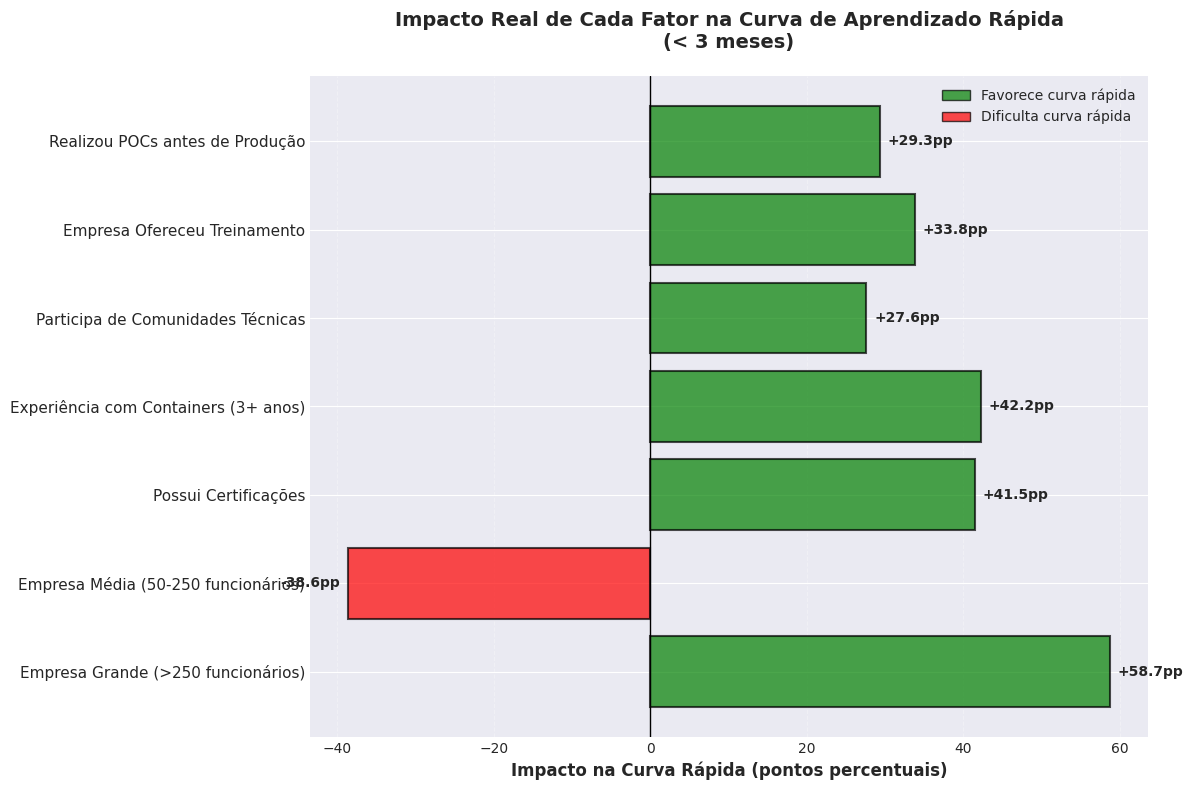


Gráfico salvo: resultados/graficos/regressao/impacto_fatores.png

NOTA: Devido à separação quase-completa, este gráfico mostra o impacto
descritivo (diferença em pontos percentuais) ao invés de Odds Ratios,
que são mais intuitivos e confiáveis para este dataset.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

if resultado_regressao['modelo'] is None:
    utils.titulo_secao("MODELO NÃO AJUSTADO - DADOS INSUFICIENTES")
    print("\nRECOMENDAÇÕES:")
    print("  1. Verificar se há dados suficientes (mínimo 30 observações)")
    print("  2. Garantir variação em ambas as classes (Y=0 e Y=1)")
    print("  3. Coletar mais dados se necessário")
else:
    # Usar análise descritiva (mais robusta que Odds Ratios com quasi-separation)
    df_analise = resultado_regressao['analise_descritiva']
    
    # Extrair diferenças (remover 'pp' e converter para float)
    diferencas = df_analise['Diferença'].str.replace('pp', '').astype(float)
    variaveis = df_analise['Variável'].values
    
    # Criar gráfico
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Cores baseadas no impacto (positivo = verde, negativo = vermelho)
    cores = ['green' if d > 0 else 'red' for d in diferencas]
    
    y_pos = np.arange(len(variaveis))
    bars = ax.barh(y_pos, diferencas.values, color=cores, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Linha de referência zero
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    
    # Adicionar valores nas barras
    for i, (bar, val) in enumerate(zip(bars, diferencas)):
        if val > 0:
            ax.text(val + 1, i, f'+{val:.1f}pp', va='center', fontweight='bold', fontsize=10)
        else:
            ax.text(val - 1, i, f'{val:.1f}pp', va='center', ha='right', fontweight='bold', fontsize=10)
    
    # Configurações do gráfico
    ax.set_yticks(y_pos)
    ax.set_yticklabels(variaveis, fontsize=11)
    ax.set_xlabel('Impacto na Curva Rápida (pontos percentuais)', fontsize=12, fontweight='bold')
    ax.set_title('Impacto Real de Cada Fator na Curva de Aprendizado Rápida\n(< 3 meses)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Legenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.7, edgecolor='black', label='Favorece curva rápida'),
        Patch(facecolor='red', alpha=0.7, edgecolor='black', label='Dificulta curva rápida')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    
    plt.tight_layout()
    
    # Salvar gráfico
    os.makedirs('../resultados/graficos/regressao', exist_ok=True)
    caminho_grafico = '../resultados/graficos/regressao/impacto_fatores.png'
    plt.savefig(caminho_grafico, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nGráfico salvo: {caminho_grafico}")
    
    # Alertar se houver quasi-separation
    if resultado_regressao.get('quasi_separacao', False):
        print("\nNOTA: Devido à separação quase-completa, este gráfico mostra o impacto")
        print("descritivo (diferença em pontos percentuais) ao invés de Odds Ratios,")
        print("que são mais intuitivos e confiáveis para este dataset.")

In [4]:
if resultado_regressao['modelo'] is None:
    utils.titulo_secao("Regressão Logística Não Concluída")
    print("\nDados insuficientes para ajustar o modelo")
    print("Consulte a célula anterior para recomendações")
else:
    utils.titulo_secao("Análise de Regressão Logística Concluída")
    print("\nResultados:")
    print("  - Modelo ajustado com sucesso")
    print("  - Análise descritiva de impacto gerada")
    print("  - Gráfico visual salvo em resultados/graficos/regressao/")
    
    if resultado_regressao.get('quasi_separacao', False):
        print("\nIMPORTANTE:")
        print("  - Separação quase-completa detectada nos dados")
        print("  - Odds Ratios não são interpretáveis")
        print("  - Use a Análise Descritiva de Impacto (mais confiável)")
    
print("\nPróximo passo:")
print("  - Gerar visualizações adicionais (05_visualizacoes.ipynb)")


ANÁLISE DE REGRESSÃO LOGÍSTICA CONCLUÍDA

Resultados:
  - Modelo ajustado com sucesso
  - Análise descritiva de impacto gerada
  - Gráfico visual salvo em resultados/graficos/regressao/

IMPORTANTE:
  - Separação quase-completa detectada nos dados
  - Odds Ratios não são interpretáveis
  - Use a Análise Descritiva de Impacto (mais confiável)

Próximo passo:
  - Gerar visualizações adicionais (05_visualizacoes.ipynb)
